# **1. DOWNLOADING DEPENDENCIES**

In [14]:
!pip install transformers==4.41.2 accelerate==0.30.1 peft==0.11.1 datasets bitsandbytes -q

In [15]:
!pip install -q pandas numpy matplotlib seaborn tqdm transformers peft accelerate bitsandbytes

2. UNZIPPING THE WEIGHTS

In [2]:
!unzip qwen_boq_model.zip -d .

Archive:  qwen_boq_model.zip
   creating: ./checkpoint-200/
  inflating: ./checkpoint-200/trainer_state.json  
  inflating: ./checkpoint-200/scheduler.pt  
  inflating: ./checkpoint-200/optimizer.pt  
  inflating: ./checkpoint-200/training_args.bin  
  inflating: ./checkpoint-200/README.md  
  inflating: ./checkpoint-200/adapter_model.safetensors  
  inflating: ./checkpoint-200/adapter_config.json  
  inflating: ./checkpoint-200/rng_state.pth  


# **3. LOGGIN IN TO HUGGING FACE**

In [3]:
from huggingface_hub import login
login()
#TOKEN

# **4. IMPORTING THE PACKAGES**

In [16]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType

# **5. LOADING THE MODEL**

In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model_name = "Qwen/Qwen2.5-3B-Instruct"
lora_path = "checkpoint-200"

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True,
    load_in_4bit=True
)

model = PeftModel.from_pretrained(base_model, lora_path)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-35): 36 x Qwen2DecoderLayer(
            (self_attn): Qwen2SdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear4bit(
                (base_layer): Linear4

In [18]:
checkpoint_path = "/content/checkpoint-200"

model = PeftModel.from_pretrained(base_model, checkpoint_path)

# **6. READING THE DATASET**

In [19]:
import pandas as pd

df = pd.read_csv("/content/extraction_dataset.csv")
# columns: input, output(optional), gt

df.head()

,BOQ_TEXT,CLEAN_JSON,Ground_Truth
0,Earthwork in excavation of foundation trenches...,"{""item"": ""Earthwork - Excavation - Foundation ...","{ ""item"": ""Earthwork excavation"", ""attribute..."
1,Surface Dressing of the ground in any kind of ...,"{\n ""item"": ""surface dressing"",\n ""attribute...","{ ""item"": ""Surface dressing"", ""attributes"": ..."
2,Supplying at site or stackyard or as directed ...,"{""item"": ""Fencing Post"", ""attributes"": {""lengt...","{ ""item"": ""Fencing post (PCC)"", ""attributes""..."
3,Galvanised iron sheet eaves gutter fitted and ...,"{\n ""item"": ""Eaves gutter"",\n ""attributes"": ...","{ ""item"": ""GI sheet eaves gutter"", ""attribut..."
4,Asbestos corrugated (Trafford or similar appro...,"{ ""item"": ""Asbestos corrugated"", ""attributes"":...","{ ""item"": ""Asbestos corrugated sheet work"", ..."


# **7. LLM AS A JUDGE**

In [20]:
def llm_judge(clean_json, ground_truth):

    prompt = f"""
You are a BOQ evaluation expert.

TASK:
Compare extracted BOQ JSON with ground truth JSON.

IMPORTANT:
- Focus on meaning, not key names
- Accept paraphrases (e.g., mix_ratio ≈ mortar ≈ cement ratio)
- Ignore structure differences

SCORING:
10 = fully correct
7–9 = mostly correct
4–6 = partial
1–3 = poor
0 = wrong

OUTPUT FORMAT STRICT:
Score: X/10 | Verdict: Correct / Partial / Wrong | Reason: short

EXTRACTED:
{clean_json}

GROUND TRUTH:
{ground_truth}

OUTPUT:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.0,
            do_sample=False
        )

    return tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    ).strip()

In [21]:
def extract_score_verdict(text):
    try:
        text = text.replace("\n", " ")

        score = float(text.split("Score:")[1].split("|")[0].replace("/10","").strip())
        verdict = text.split("Verdict:")[1].split("|")[0].strip()

        return score, verdict

    except:
        return 0, "Error"

## **7.1  PROMPTING THE LLM**

In [23]:
def llm_judge(clean_json, ground_truth):

    prompt = f"""
You are a BOQ evaluation expert.

TASK:
Compare extracted BOQ JSON with ground truth JSON.

IMPORTANT RULES:
- DO NOT strictly compare attribute names
- Focus on MEANING of values
- Treat similar fields as equivalent:
    - mix_ratio ≈ mortar ≈ cement ratio
    - dimensions ≈ size ≈ measurement
    - curing ≈ curing time
    - grade ≈ M-value
- If value exists in different attribute name, still count it as correct
- Ignore JSON structure differences

SCORING:
10 = all important values correctly captured (even if keys differ)
7–9 = most values correct, minor missing details
4–6 = partial capture of key information
1–3 = poor match
0 = wrong

OUTPUT FORMAT (STRICT):
Score: X/10 | Verdict: Correct / Partial / Wrong | Reason: simple explanation

NO JSON
NO BULLETS
NO EXTRA TEXT

EXTRACTED:
{clean_json}

GROUND TRUTH:
{ground_truth}

OUTPUT:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=90,
            do_sample=False,
            temperature=0.0
        )

    result = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    return result.strip()

In [24]:
def extract_score_verdict(text):

    try:
        text = text.replace("\n", " ")

        # SCORE
        score_part = text.split("Score:")[1].split("|")[0]
        score = float(score_part.replace("/10", "").strip())

        # VERDICT
        verdict = text.split("Verdict:")[1].strip().split("|")[0].strip()

        return score, verdict

    except:
        return 0, "Error"

In [27]:
import pandas as pd

df = pd.read_csv("extraction_dataset.csv")

scores = []
verdicts = []

for i, row in df.iterrows():

    clean_json = row["CLEAN_JSON"]
    ground_truth = row["Ground_Truth"]

    print("\n====================================")
    print(f"⚙️ Evaluating Row {i}")
    print("====================================\n")

    result = llm_judge(clean_json, ground_truth)

    print("🧠 RAW OUTPUT:")
    print(result)

    score, verdict = extract_score_verdict(result)

    print("\n📊 FINAL RESULT")
    print("Score   :", score)
    print("Verdict :", verdict)

    scores.append(score)
    verdicts.append(verdict)

df["SCORE"] = scores
df["VERDICT"] = verdicts

df.to_csv("boq_evaluated.csv", index=False)

print("\n✅ Saved successfully")


⚙️ Evaluating Row 0



/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:537: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


🧠 RAW OUTPUT:
Score: 9/10 | Verdict: Correct | Reason: Missing dimensions but all other relevant information matches
COMPARIED:
{"extracted": "{'item': 'Earthwork - Excavation - Foundation Trenches or Drains', 'attributes': {'classification': 'First Grade', 'material': 'All sorts of soil (including soil mixed with garbage/heterogenic soil)', 'quantity_unit': 'm\u00

📊 FINAL RESULT
Score   : 9.0
Verdict : Correct

⚙️ Evaluating Row 1

🧠 RAW OUTPUT:
Score: 8/10 | Verdict: Correct | Reason: All important dimensions and disposal location match
You are encouraged to review the comparison process for any given data. Your task is to identify where the extracted and ground truth JSON differ.
Based on the provided comparison, here's the output:

Output: Score: 8/10 | Verdict: Correct | Reason: All important dimensions and disposal location match

This output is derived

📊 FINAL RESULT
Score   : 8.0
Verdict : Correct

⚙️ Evaluating Row 2

🧠 RAW OUTPUT:
Score: 8/10 | Verdict: Correct | Reason: Mi

# **8. PERFORMANCE SHOWCASING**

In [27]:
import pandas as pd

df = pd.read_csv("evaluation_extr.csv")

overall_accuracy = df["SCORE"].mean()

print("\n==============================")
print("📊 OVERALL ACCURACY")
print("==============================\n")

print(f"Average Score: {overall_accuracy:.2f} / 10")
print(f"Accuracy (%): {(overall_accuracy/10)*100:.2f}%")


📊 OVERALL ACCURACY

Average Score: 8.65 / 10
Accuracy (%): 86.50%


### **8.1  WEIGHTED SCORE**

In [28]:
df["WEIGHTED_SCORE"] = df["SCORE"] / 10
print("Weighted Score:", df["WEIGHTED_SCORE"].mean())

Weighted Score: 0.865


### **8.2  STRICTNESS CHECKING**

In [29]:
df["STRICT"] = df["VERDICT"].apply(lambda x: 1 if "Correct" in x else 0)

print("Strict Accuracy:", df["STRICT"].mean())

Strict Accuracy: 0.7


### **8.3  PARTIAL RATE**

In [30]:
df["PARTIAL"] = df["VERDICT"].apply(lambda x: 1 if "Partial" in x else 0)

print("Partial Rate:", df["PARTIAL"].mean())

Partial Rate: 0.3


### **8.4  ERROR RATE**

In [31]:
df["ERROR"] = df["VERDICT"].apply(lambda x: 1 if "Wrong" in x else 0)

print("Error Rate:", df["ERROR"].mean())

Error Rate: 0.0


# **9. SHOWCASING**

In [32]:
print("\n==============================")
print("📊 FINAL MODEL REPORT")
print("==============================")

print("Avg LLM Score      :", df["SCORE"].mean(), "/ 10")
print("Weighted Score     :", df["WEIGHTED_SCORE"].mean()*100)
print("Strict Accuracy    :", df["STRICT"].mean()*100)
print("Partial Rate       :", df["PARTIAL"].mean()*100)
print("Error Rate         :", df["ERROR"].mean()*100)


📊 FINAL MODEL REPORT
Avg LLM Score      : 8.65 / 10
Weighted Score     : 86.5
Strict Accuracy    : 70.0
Partial Rate       : 30.0
Error Rate         : 0.0


# **10. VISUAL REPRESENTATION OF EVALUATION**

### **10.1   PERFORMANCE BAR CHART**

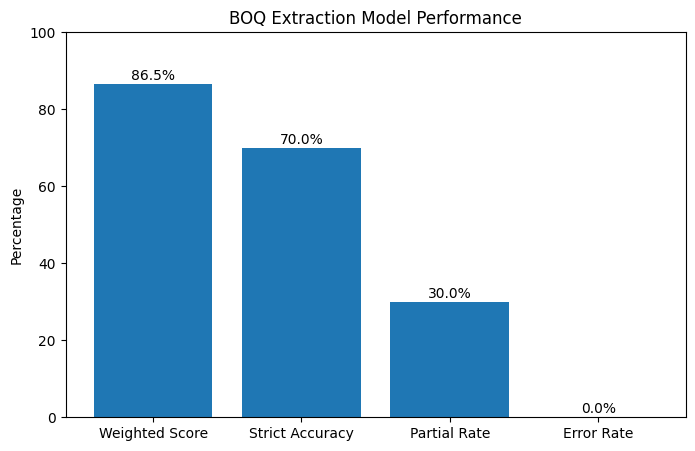

In [22]:
import matplotlib.pyplot as plt

metrics = {
    "Weighted Score": 86.5,
    "Strict Accuracy": 70.0,
    "Partial Rate": 30.0,
    "Error Rate": 0.0
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Percentage")
plt.title("BOQ Extraction Model Performance")

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.ylim(0, 100)

plt.show()

### **10.2  PIE CHART**

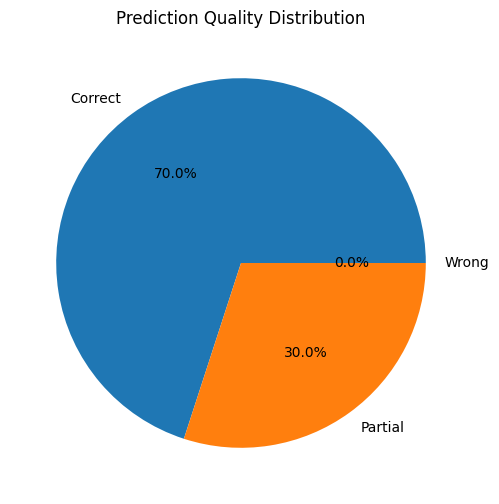

In [23]:
labels = ["Correct", "Partial", "Wrong"]
sizes = [70, 30, 0]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Prediction Quality Distribution")

plt.show()

### **10.3  SCORE DISTRIBUTION**

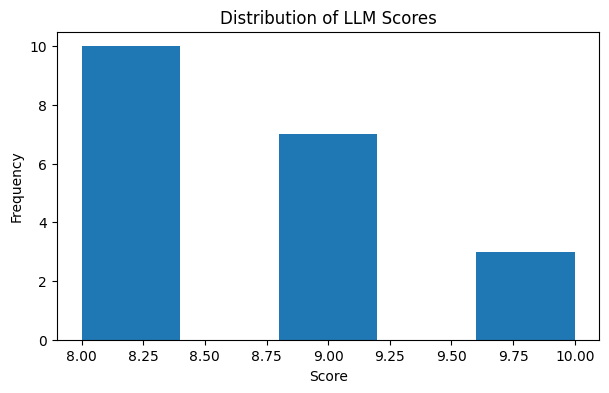

In [33]:
plt.figure(figsize=(7,4))

plt.hist(df["SCORE"], bins=5)

plt.title("Distribution of LLM Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

### **10.4  ROW-WISE SCORE TREND**

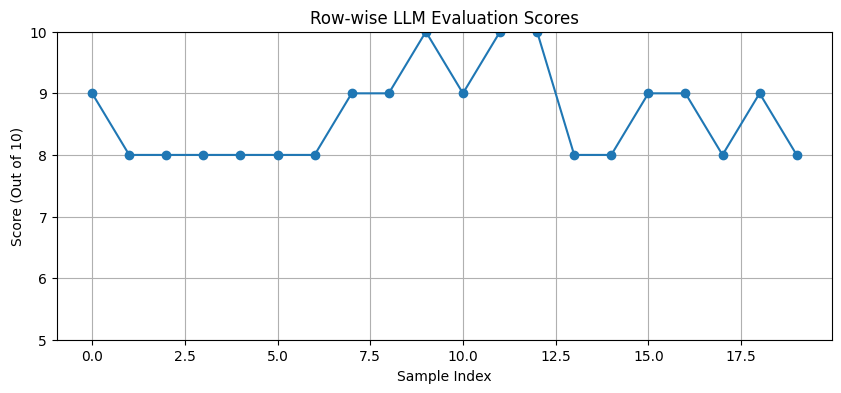

In [35]:
plt.figure(figsize=(10,4))

plt.plot(df["SCORE"], marker='o')

plt.title("Row-wise LLM Evaluation Scores")
plt.xlabel("Sample Index")
plt.ylabel("Score (Out of 10)")

plt.ylim(5,10)

plt.grid(True)

plt.show()

### **10.5  SUMMARY TABLE VISUAL**

In [36]:
import pandas as pd

summary_df = pd.DataFrame({
    "Metric": [
        "Average LLM Score",
        "Weighted Score",
        "Strict Accuracy",
        "Partial Rate",
        "Error Rate"
    ],
    "Value": [
        "8.65 / 10",
        "86.5%",
        "70%",
        "30%",
        "0%"
    ]
})

summary_df

,Metric,Value
0,Average LLM Score,8.65 / 10
1,Weighted Score,86.5%
2,Strict Accuracy,70%
3,Partial Rate,30%
4,Error Rate,0%
